# Project 5B: Flow Matching from Scratch!

## Setup environment

In [5]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
%pip install mediapy einops --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import essential modules. Feel free to add whatever you need.
import os
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm

curr_dir = os.path.dirname(os.path.abspath("__file__"))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [20]:
class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.Conv2d(in_channels, out_channels, 3, 1, 1)
        self.BN = nn.BatchNorm2d(out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        out = self.conv(x)
        out = self.BN(out)
        out = F.gelu(out)
        return out
        # ===== end of code ====
        raise NotImplementedError()


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.Conv2d(in_channels, out_channels, 3, 2, 1)
        self.BN = nn.BatchNorm2d(out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        out = self.conv(x)
        out = self.BN(out)
        out = F.gelu(out)
        return out
        # ===== end of code ====
        raise NotImplementedError()


class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1)
        self.BN = nn.BatchNorm2d(out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        out = self.conv(x)
        out = self.BN(out)
        out = F.gelu(out)
        return out
        # ===== end of code ====
        raise NotImplementedError()


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        # ===== your code here! ====
        self.AvgPool = nn.AvgPool2d(7)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        out = self.AvgPool(x)
        out = F.gelu(out)
        return out
        # ===== end of code ====
        raise NotImplementedError()


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.ConvTranspose2d(in_channels, in_channels, 7, 7, 0)
        self.BN = nn.BatchNorm2d(in_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        out = self.conv(x)
        out = self.BN(out)
        out = F.gelu(out)
        return out
        # ===== end of code ====
        raise NotImplementedError()


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv1 = Conv(in_channels, out_channels)
        self.conv2 = Conv(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        out = self.conv1(x)
        out = self.conv2(out)
        return out
        # ===== end of code ====
        raise NotImplementedError()


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.down = DownConv(in_channels, out_channels)
        self.conv = ConvBlock(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        out = self.down(x)
        out = self.conv(out)
        return out
        # ===== end of code ====
        raise NotImplementedError()


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.up = UpConv(in_channels, out_channels)
        self.conv = ConvBlock(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        out = self.up(x)
        out = self.conv(out)
        return out
        # ===== end of code ====
        raise NotImplementedError()

## Implementing Unconditional UNet

In [ ]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        self.conv1 = ConvBlock(in_channels, num_hiddens)
        self.down1 = DownBlock(num_hiddens, num_hiddens)
        self.down2 = DownBlock(num_hiddens, 2*num_hiddens)
        self.flat1 = Flatten()
        self.unflat1 = Unflatten(2*num_hiddens)
        self.up1 = UpBlock(4*num_hiddens, num_hiddens)
        self.up2 = UpBlock(2*num_hiddens, num_hiddens)
        self.conv2 = ConvBlock(2*num_hiddens, num_hiddens)
        self.final_conv = nn.Conv2d(num_hiddens, in_channels, 3, 1, 1)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        conv1 = self.conv1(x)
        down1 = self.down1(conv1)
        down2 = self.down2(down1)
        flat1 = self.flat1(down2)
        unflat1 = self.unflat1(flat1)
        up1 = self.up1(torch.cat([unflat1, down2], dim=1))
        up2 = self.up2(torch.cat([up1, down1], dim=1))
        conv2 = self.conv2(torch.cat([up2, conv1], dim=1))
        out = self.final_conv(conv2)
        return out
        # ===== end of code ====
        raise NotImplementedError()

# Part 1.2: Using the UNet to Train a Denoiser

In [ ]:
import os
from torchvision.utils import save_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# Visualize images at different noisy level
# ===== your code here! ====
sigma = 0.5

curr_dir = os.path.dirname(os.path.abspath("__file__"))
target_dir = os.path.join(curr_dir, "B_1_2_1")
train_dataset = torchvision.datasets.MNIST(curr_dir, True, torchvision.transforms.ToTensor(), None, True)
test_dataset = torchvision.datasets.MNIST(curr_dir, False, torchvision.transforms.ToTensor(), None, True)

train_dataloader = DataLoader(train_dataset, 256, True)
test_dataloader = DataLoader(test_dataset, 256, False)

model = UnconditionalUNet(1, 128).to(device)
optim = torch.optim.AdamW(model.parameters(), lr = 1e-4)
criterion = nn.MSELoss()

# print(len(train_dataset))


for i in range(5):
    model.train()
    training_loss = 0.00

    for x, y in train_dataloader:
        x = x.to(device)
        noisy_x = x + torch.randn_like(x) * sigma

        x_hat = model(noisy_x)

        loss = criterion(x_hat, x)
        optim.zero_grad()
        loss.backward()
        optim.step()

        training_loss += loss.item() * x.size(0)
    
    print(f"Trained Loop {i+1}")
    
    epoch_loss = training_loss / len(train_dataset)
    print(f"Epoch {i+1}/{i} | Loss = {epoch_loss:.4f}")
    
    
    model.eval()
    with torch.no_grad():
        indices = [0, 10, 25, 100, 256]
        images = torch.stack([test_dataset[i][0] for i in indices])
        images = images.to(device)

        noise = torch.randn_like(images)
        noisy_x = images + sigma * noise
        x_hat = model(noisy_x)

        for j, clean in enumerate(images):
            save_image(clean, os.path.join(target_dir, f"clean_{j}.jpg"))
        for j, noisy in enumerate(noisy_x):
            save_image(noisy, os.path.join(target_dir, f"{i}_noisy_{j}.jpg"))
        for j, pred in enumerate(x_hat):
            save_image(pred, os.path.join(target_dir, f"{i}_pred_{j}.jpg"))
    
    print(f"Saved Loop {i+1}")

    # if i == 4:
    #     model.eval()
    #     test_loss = 0.0
    #     with torch.no_grad():
    #         for x, y in test_dataloader:
    #             x.to(device)
    #             noisy_x = x + torch.randn_like(x) * sigma

    #             x_hat = model(noisy_x)

    #             loss = criterion(x_hat, x)
    #             test_loss += loss.item() * x.size(0)
        
    #     epoch_loss = training_loss / len(train_dataset)
    #     print(f"Round {i+1}/{i} | Test Loss = {epoch_loss:.4f}")


# ===== end of code ====

cuda
Trained Loop 1
Epoch 1/0 | Loss = 0.0224
Saved Loop 1
Trained Loop 2
Epoch 2/1 | Loss = 0.0111
Saved Loop 2
Trained Loop 3
Epoch 3/2 | Loss = 0.0095
Saved Loop 3
Trained Loop 4
Epoch 4/3 | Loss = 0.0087
Saved Loop 4
Trained Loop 5
Epoch 5/4 | Loss = 0.0083
Saved Loop 5


## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [ ]:
device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = None
learning_rate = None
noise_level = None
hidden_dim = None
num_epochs = None
# ===== end of code ====

In [ ]:
# Define your datasets and dataloaders
# ===== your code here! ====
train_dataset = None
test_dataset = None
train_loader = None
test_loader = None
# ===== end of code ====

In [ ]:
# Define your model, optimizer, and loss
# ===== your code here! ====
model = None
optimizer = None
criterion = None
# ===== end of code ====

In [ ]:
# The training loops
train_losses = []
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(tqdm(train_loader)):

        # ===== your code here! ====

        outputs = None

        # ===== end of code ====

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

In [ ]:
# Visualize your training curve
# ===== your code here! ====

# ===== end of code ====

## Part 1.2.2: Out-of-Distribution Testing

In [ ]:
# Visualize OOD testing
# ===== your code here! ====

target_dir = os.path.join(curr_dir, "B_1_2_2")

indices = [0, 10, 25, 100, 256]
images = torch.stack([test_dataset[i][0] for i in indices])
images = images.to(device)

for sigma in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    model.eval()
    with torch.no_grad():
        noise = torch.randn_like(images)
        noisy_x = images + sigma * noise
        x_hat = model(noisy_x)

        for j, clean in enumerate(images):
            save_image(clean.cpu(), os.path.join(target_dir, f"clean_{j}.jpg"))
        for j, noisy in enumerate(noisy_x):
            save_image(noisy.cpu(), os.path.join(target_dir, f"{sigma}_noisy_{j}.jpg"))
        for j, pred in enumerate(x_hat):
            save_image(pred.cpu(), os.path.join(target_dir, f"{sigma}_pred_{j}.jpg"))

# ===== end of code ====

## Part 1.2.3 Denoising Pure Noise

Trained Loop 1
Epoch 1/0 | Loss = 0.1971
Saved Loop 1
Trained Loop 2
Epoch 2/1 | Loss = 0.1972
Saved Loop 2
Trained Loop 3
Epoch 3/2 | Loss = 0.1971
Saved Loop 3
Trained Loop 4
Epoch 4/3 | Loss = 0.1972
Saved Loop 4
Trained Loop 5
Epoch 5/4 | Loss = 0.1971
Saved Loop 5


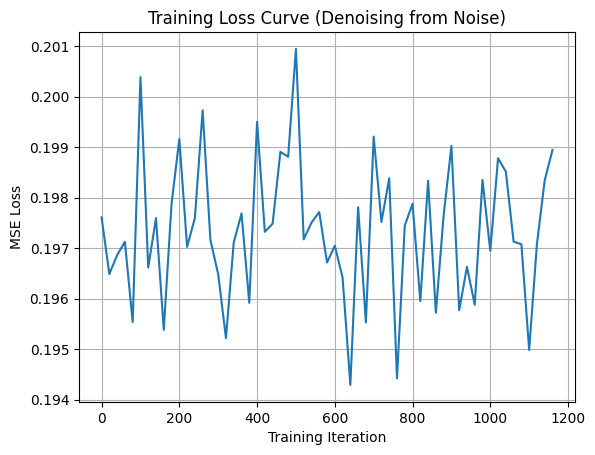

In [30]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
import os
from torchvision.utils import save_image

target_dir = os.path.join(curr_dir, "B_1_2_3")

model_pure_noise = UnconditionalUNet(1, 128).to(device)
optim_pure_noise = torch.optim.AdamW(model.parameters(), lr = 1e-4)
criterion = nn.MSELoss()

losses = []
iters = []

num_batches = len(train_dataloader)

for i in range(5):
    model_pure_noise.train()
    training_loss = 0.00

    for iter, (x, y) in enumerate(train_dataloader):
        x = x.to(device)
        pure_noise = torch.rand_like(x).to(device)

        x_hat = model_pure_noise(pure_noise)

        loss = criterion(x_hat, x)
        optim_pure_noise.zero_grad()
        loss.backward()
        optim_pure_noise.step()

        training_loss += loss.item() * x.size(0)

        if (iter + i*num_batches)%20 == 0: 
            losses.append(loss.item())
            iters.append(iter + i*num_batches)
    
    print(f"Trained Loop {i+1}")
    
    epoch_loss = training_loss / len(train_dataset)
    print(f"Epoch {i+1}/{i} | Loss = {epoch_loss:.4f}")
    
    
    model_pure_noise.eval()
    with torch.no_grad():
        noises = torch.randn((5, 1, 28, 28)).to(device)
        x_hat = model_pure_noise(noises)

        for j, noise in enumerate(noises):
            save_image(noise.cpu(), os.path.join(target_dir, f"{i}_noise_{j}.jpg"))
        for j, pred in enumerate(x_hat):
            save_image(pred.cpu(), os.path.join(target_dir, f"{i}_pred_{j}.jpg"))
    
    print(f"Saved Loop {i+1}")

plt.plot(iters, losses)
plt.xlabel("Training Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve (Denoising from Noise)")
plt.grid(True)
plt.savefig(os.path.join(target_dir, f"Training Loss Plot.png"), dpi=300, bbox_inches="tight")
plt.show()

# ===== end of code ====

# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [ ]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====

        # ===== end of code ====
        raise NotImplementedError()


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====

        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====

        # ===== end of code ====
        raise NotImplementedError()

## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [ ]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====

    # ===== end of code ====
    raise NotImplementedError()

In [ ]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # ===== your code here! ====

    # ===== end of code ====
    raise NotImplementedError()

In [ ]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Part 2.2: Training the Time-conditioned UNet

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====

# ===== end of code ====

# Part 2.3: Sampling from the Time-conditioned UNet

In [ ]:
# Sampling from the UNet
# ===== your code here! ====

# ===== end of code ====

# Part 2.4: Implementing a Class-conditioned UNet

In [ ]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====

        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====

        # ===== end of code ====
        raise NotImplementedError()

In [ ]:
def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====

    # ===== end of code ====
    raise NotImplementedError()

In [ ]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # ===== your code here! ====

    # ===== end of code ====
    raise NotImplementedError()

In [ ]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====

# ===== end of code ====

# Part 2.6: Sampling from the Class-conditioned UNet

In [ ]:
# Sampling from the UNet
# ===== your code here! ====

# ===== end of code ====